In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np
import hdbscan

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["mace"])
df = qm9.load()

2026-05-07 08:24:05.600 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-07 08:24:06.495 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-05-07 08:24:06.497 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-05-07 08:24:06.497 | INFO     | src.features:compute_mace_outputs:678 - Computing MACE embeddings (model=medium, batch_size=32)...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
INFO: Using CPU
INFO: Using head Default out of  ['Default']
2026-05-07 08:41:52.797 | SUCCESS  | src.datasets:add_mace:1286 - Added MACE embeddings and matrices.
2026-05-07 08:41:53.036 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['mace_embedding', 'mace_matrix']
2026-05-07 08:41:53.166 | INFO     | src.datasets:load:907 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=5000, returned_rows=5000, base_rows=5500.


In [ ]:
print(len(df["mace_embedding"].to_list()[0]))

In [5]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="mace",
    dist_type="euclidean",
    force_calculate=True,
)

2026-05-07 08:41:53.503 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for mace using euclidean distance.
2026-05-07 08:41:55.970 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_mace_euclidean.npy


In [6]:
molecules = qm9.get_molecules()
len(molecules[0:2])

2026-05-07 08:42:00.467 | SUCCESS  | src.datasets:get_molecules:1689 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


2

In [7]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:23<00:00,  2.35s/it]


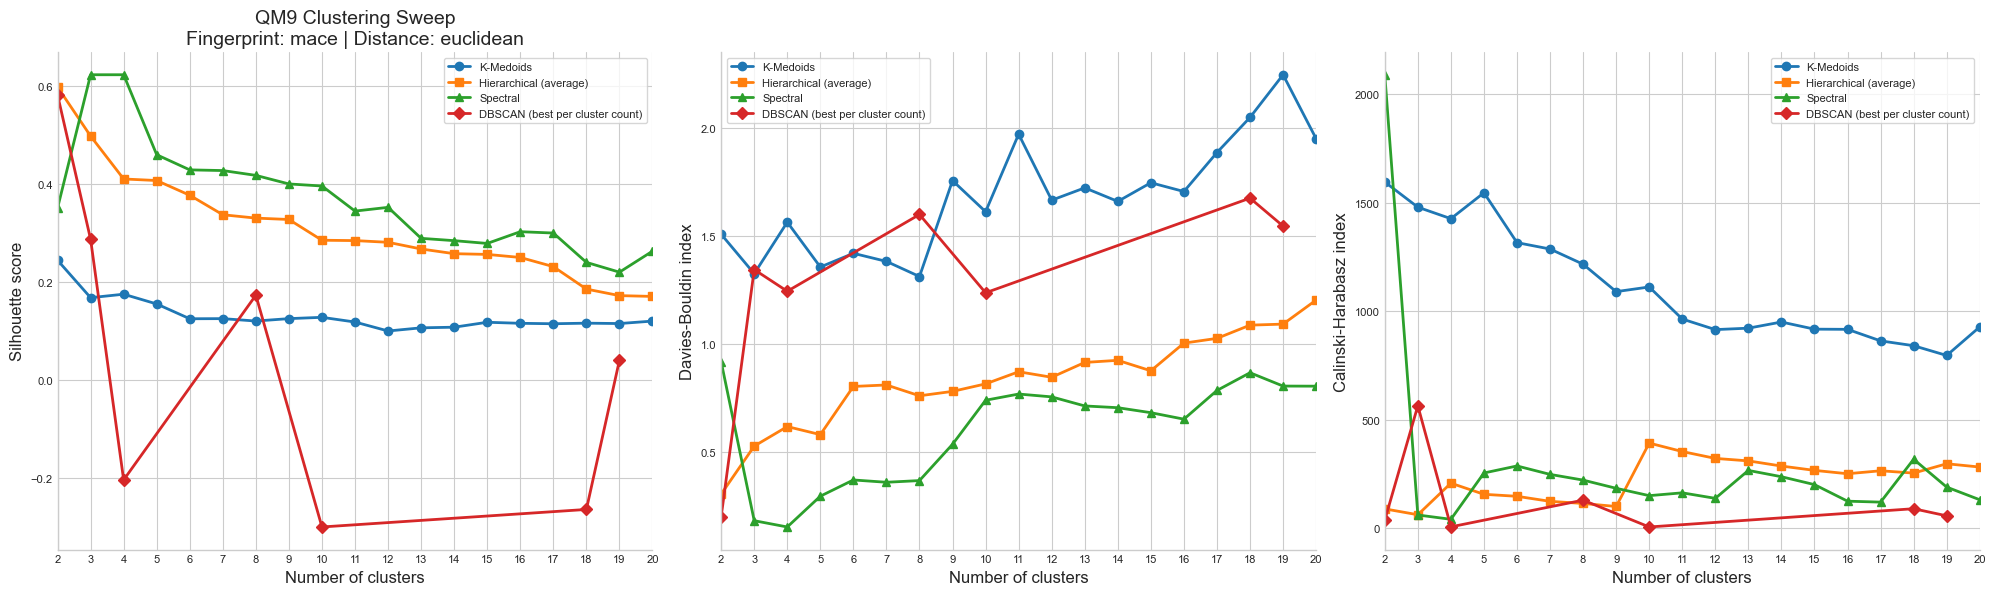

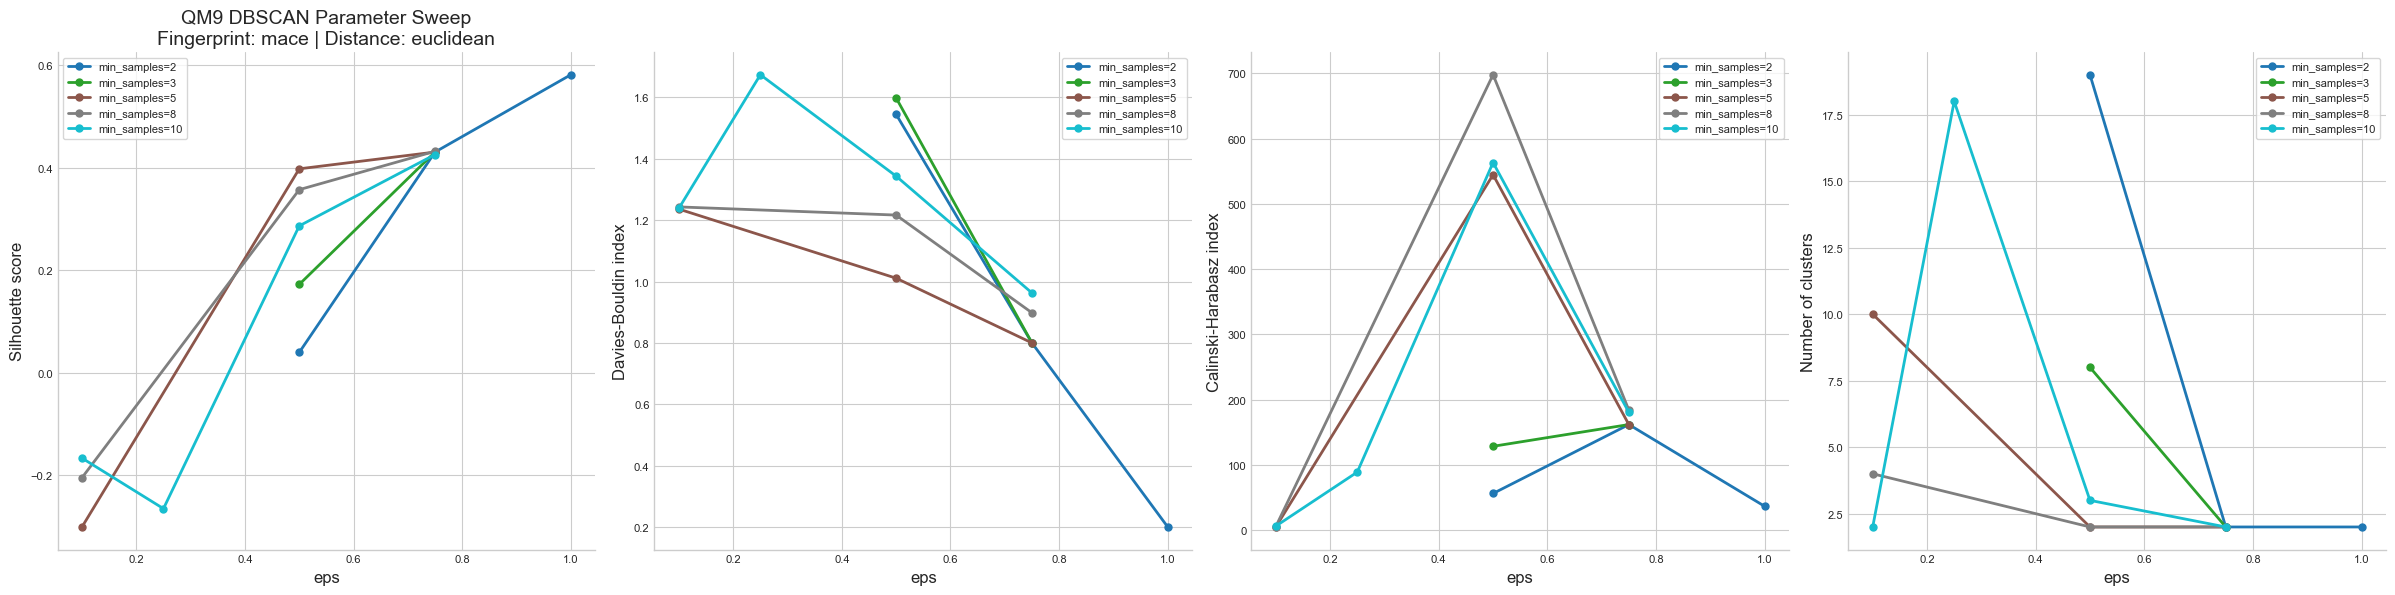

2026-05-07 08:45:01.032 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1059 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/mace/clustering_sweep_2_to_20_clusters.png
2026-05-07 08:45:01.034 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1061 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/mace/dbscan_parameter_sweep.png
2026-05-07 08:45:01.035 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved clustering sweep results to figures/qm9/clustering/euclidean/mace/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4440), np.int64(4452)), (np.int64(2368), np.int64(2372)), (np.int64(4978), np.int64(4979)), (np.int64(3770), np.int64(3771)), (np.int64(2322), np.int64(4092)), (np.int64(4614), np.int64(4625)), (np.int64(2473), np.int64(4142)), (np.int64(3473), np.int64(3486)), (np.int64(290), np.int64(291)), (np.int64(3782), np.int64(3786))]


In [10]:
print(mols[0])

(Atoms(symbols='C6OC2H12', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='C6OC2H12', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

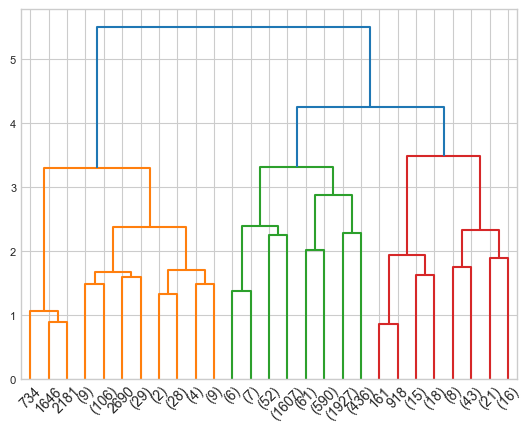

In [12]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [13]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3]), array([4686,  191,   88,   35]))


In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-05-07 08:45:09.718 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:45:09.720 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:46:33.253 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:46:33.400 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:46:33.775 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:46:33.882 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

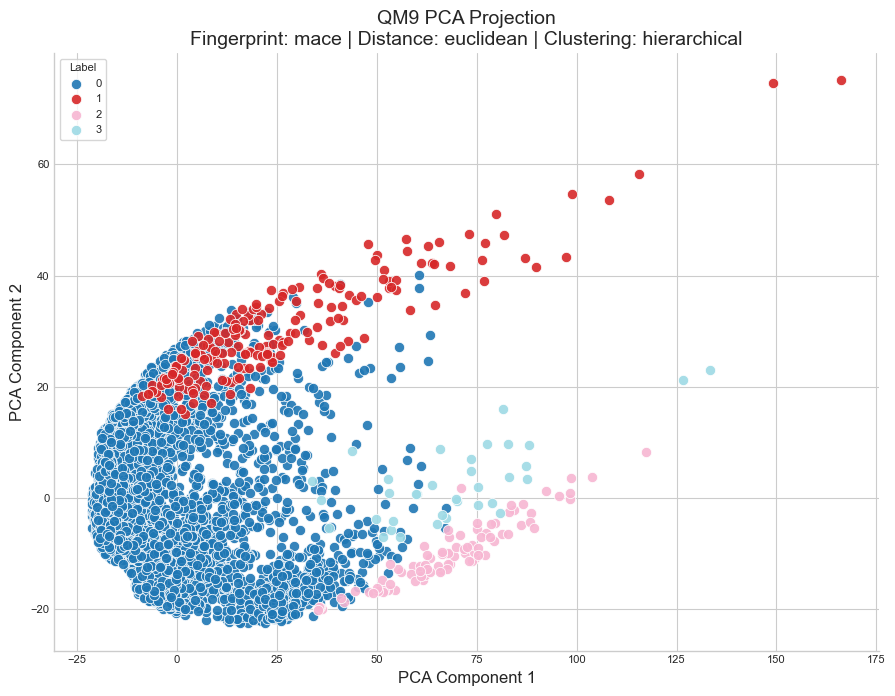

2026-05-07 08:46:35.295 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/mace/pca_hierarchical_projection.png


{'coords': array([[ 21.54159562, -14.16967919],
        [ -0.2144445 ,  -8.95798267],
        [  3.97421007,  17.05655842],
        ...,
        [-15.75932312,  -4.07954351],
        [ -2.81004095, -10.83458739],
        [ -0.57005128,  -1.391273  ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/mace/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/mace'),
 'clustering_method': 'hierarchical'}

In [15]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [16]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

# KMedoids

In [17]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([1681, 1684, 1635]))


In [18]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 08:46:36.962 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:46:36.968 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:47:49.086 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:47:49.196 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:47:49.707 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:47:49.843 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

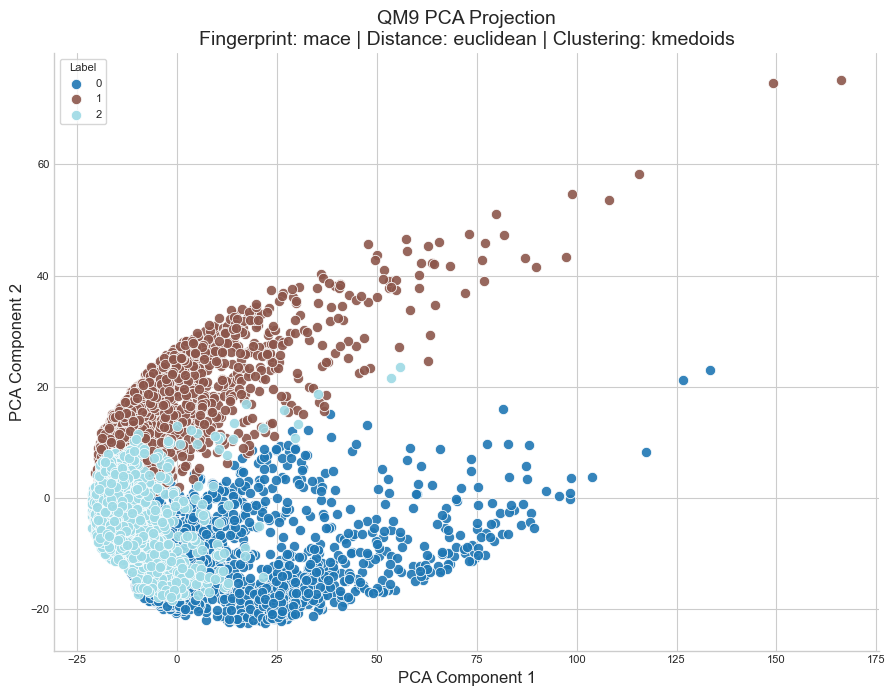

2026-05-07 08:47:50.535 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/mace/pca_kmedoids_projection.png


In [19]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [20]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1681,0.792615,0.0,121.267698,-0.032719,48.478882,0.799309,12.871367,8.712076,0.9768,0.30934,0.012493,3.007733,16.349197,1.996283,2.185604,0.120115,0.413908,0.465976,1.013682,2.405116,5.782272,0.753718,2.253421,2.697204,6.439024,12.753123,1.257293,0.004759,0.20464,0.066627,0.267103,0.28257,0.001785,0.063653,0.187388,0.33135,0.000595,3.291259,72.82157,-6.547827,-0.531244,6.016594,1216.240814,3.44335,-11365.772055,-11365.539919,-11365.514242,-11366.69163,30.74556,-70.017243,-70.404608,-70.791996,-65.317915,3.727952,1.341795,1.020832,0.167162,48.602023,30.160619,21.237359,12.753123,450,"""Acyclic""",21.237359,81,"""C1CCCC1""",22.30815,1,null,0.0
1,1684,0.80996,0.0,123.64905,-0.266033,34.247625,0.914698,12.820724,8.817696,2.562352,0.001188,0.001781,2.352138,18.626485,2.148953,1.887767,0.043301,0.04431,0.912389,1.126485,2.035629,6.714371,0.282067,0.264252,5.91924,6.092637,14.91152,1.274349,0.0,0.597981,0.000594,0.059976,0.043943,0.001781,0.035629,0.06829,0.8462,0.0,2.442835,73.338082,-6.550401,1.08933,7.639748,1085.074584,4.147452,-11283.537961,-11283.319343,-11283.293631,-11284.425596,30.921473,-76.377302,-76.863829,-77.308382,-70.99936,3.188725,1.531171,1.27626,0.11342,99.465558,0.118765,0.415677,14.91152,777,"""C1OC2CC12""",3.028504,277,"""C1CC2CC12""",10.807601,1,null,0.0
2,1635,0.675462,0.0,122.940673,0.492355,24.198165,0.923709,12.805761,8.790214,1.549847,0.017737,0.0,1.655046,20.556575,2.048291,2.839144,0.040821,0.138997,0.820182,0.656269,1.393272,7.179817,0.30581,0.983486,5.845872,6.497248,13.746789,1.25697,0.0,0.341284,0.001835,0.053823,0.080734,0.000612,0.023242,0.144343,0.438532,0.0,2.247901,80.080765,-6.519387,0.562345,7.081716,1266.690153,4.767927,-10711.071746,-10710.825064,-10710.799377,-10711.997231,33.971298,-84.152395,-84.688348,-85.184591,-78.240713,3.20873,1.32252,1.080598,0.0,88.868502,1.7737,9.357798,13.746789,488,"""Acyclic""",9.357798,158,"""C1CC1""",14.006116,1,null,0.0


# Spectral

In [45]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
model_spectral = SpectralClustering(
                n_clusters=7,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([4915,    1,    1,    8,    1,   18,   56]))


In [22]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 08:47:54.358 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:47:54.360 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:48:51.230 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:48:51.270 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:48:51.568 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:48:51.652 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

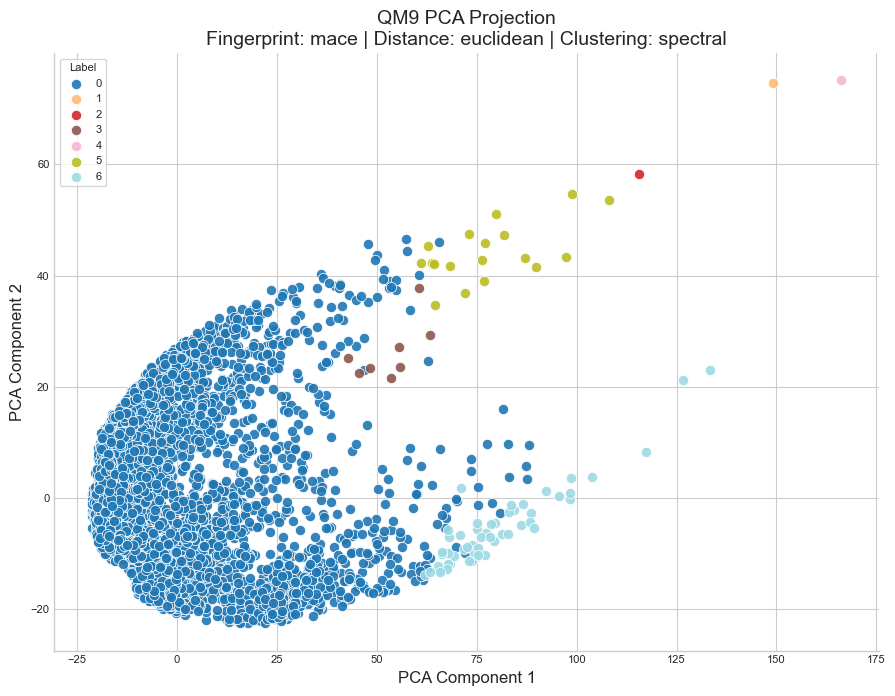

2026-05-07 08:57:50.199 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/mace/pca_spectral_projection.png


In [46]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [24]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4997,0.759917,0.0,122.618371,0.060436,35.750851,0.878713,12.833004,8.773264,1.696018,0.110266,0.004803,2.344407,18.494697,2.064548,2.29978,0.068289,0.199618,0.732093,0.935361,1.94937,6.553932,0.448269,1.168701,4.811887,6.341605,13.803682,1.262914,0.001601,0.382029,0.023214,0.127677,0.136282,0.001401,0.041025,0.13308,0.538723,0.0002,2.665051,75.376166,-6.53927,0.372393,6.911667,1188.718072,4.114458,-11123.607187,-11123.374822,-11123.34913,-11124.517958,31.862871,-76.791239,-77.260662,-77.702964,-71.466196,3.376259,1.399133,1.126273,0.093856,0.990794,78.887332,10.76646,10.346208,13.803682,1476,"""Acyclic""",10.346208,342,"""C1CCCC1""",10.806484,1,null,0.0
1,2,1.15,0.0,117.0,0.0,24.0,1.112363,12.549866,8.5,5.5,0.0,0.0,2.5,13.5,2.366667,0.5,0.166667,0.0,0.833333,0.0,2.5,5.0,1.0,0.0,5.0,6.0,15.5,1.296689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.89915,63.035,-6.831419,0.519737,7.349795,886.238251,2.615259,-11412.267578,-11412.089844,-11412.063477,-11413.112305,25.301999,-58.495384,-58.837692,-59.158907,-54.498575,4.20508,1.6695,1.418015,1.0,1.0,100.0,0.0,0.0,15.5,2,"""O1C2C3OC2C13""",50.0,2,"""C1C2C3CC2C13""",50.0,1,null,0.0
2,1,1.133333,0.0,126.0,0.0,35.0,1.0987483,12.6671,9.0,5.0,0.0,0.0,3.0,15.0,2.266667,2.0,0.0,0.166667,0.833333,0.0,3.0,6.0,0.0,1.0,5.0,6.0,17.0,1.284701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,2.598,65.669998,-6.576992,-1.042196,5.534796,1008.124207,2.964898,-12453.407227,-12453.192383,-12453.166992,-12454.345703,28.750999,-64.716034,-65.079956,-65.439743,-60.320408,3.20003,1.56134,1.19627,1.0,1.0,100.0,0.0,0.0,17.0,1,"""O1C2C3OC2C13""",100.0,1,"""C1C2C3CC2C13""",100.0,1,null,0.0


# DBSCAN 

In [25]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16]), array([ 375, 4549,    6,    3,    5,   11,    5,    6,    4,    5,    6,
          3,    4,    4,    3,    3,    5,    3]))


In [26]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 08:48:52.957 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:48:52.958 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:49:56.835 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:49:57.031 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:49:57.457 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:49:57.548 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

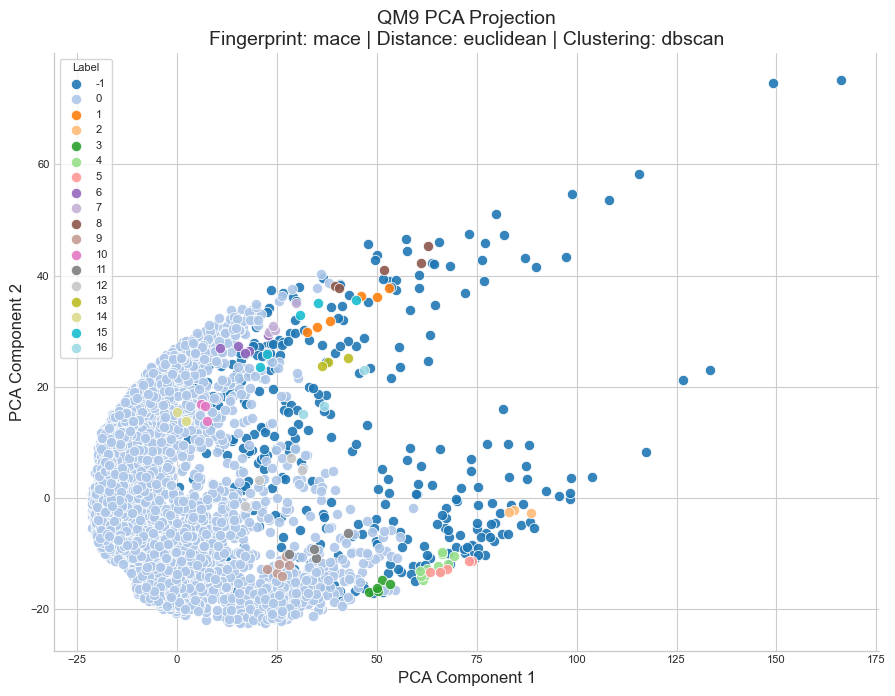

2026-05-07 08:49:58.623 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/mace/pca_dbscan_projection.png


{'coords': array([[ 21.54159562, -14.16967919],
        [ -0.2144445 ,  -8.95798267],
        [  3.97421007,  17.05655842],
        ...,
        [-15.75932312,  -4.07954351],
        [ -2.81004095, -10.83458739],
        [ -0.57005128,  -1.391273  ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/mace/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/mace'),
 'clustering_method': 'dbscan'}

In [27]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [28]:
d =average_numeric_by_cluster(df, "labels_db")

shape: (18, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

# HDBSCAN

In [29]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=3, noise=0.36, persistence=0.157, score=0.101
mcs=300, ms=1, clusters=3, noise=0.36, persistence=0.147, score=0.095
mcs=80, ms=1, clusters=5, noise=0.34, persistence=0.101, score=0.067
mcs=150, ms=1, clusters=4, noise=0.32, persistence=0.096, score=0.065
mcs=60, ms=1, clusters=5, noise=0.34, persistence=0.094, score=0.062
mcs=120, ms=1, clusters=5, noise=0.34, persistence=0.091, score=0.060
mcs=20, ms=1, clusters=25, noise=0.39, persistence=0.080, score=0.049
mcs=20, ms=2, clusters=23, noise=0.42, persistence=0.081, score=0.047
mcs=10, ms=2, clusters=2, noise=0.00, persistence=0.045, score=0.044
mcs=10, ms=1, clusters=2, noise=0.00, persistence=0.043, score=0.043
mcs=10, ms=1, clusters=2, noise=0.00, persistence=0.043, score=0.043
mcs=40, ms=1, clusters=6, noise=0.33, persistence=0.059, score=0.039
mcs=40, ms=4, clusters=6, noise=0.46, persistence=0.072, score=0.039


In [30]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=80,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [31]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 08:51:10.694 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:51:10.744 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:52:22.702 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:52:22.783 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:52:23.152 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:52:23.253 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

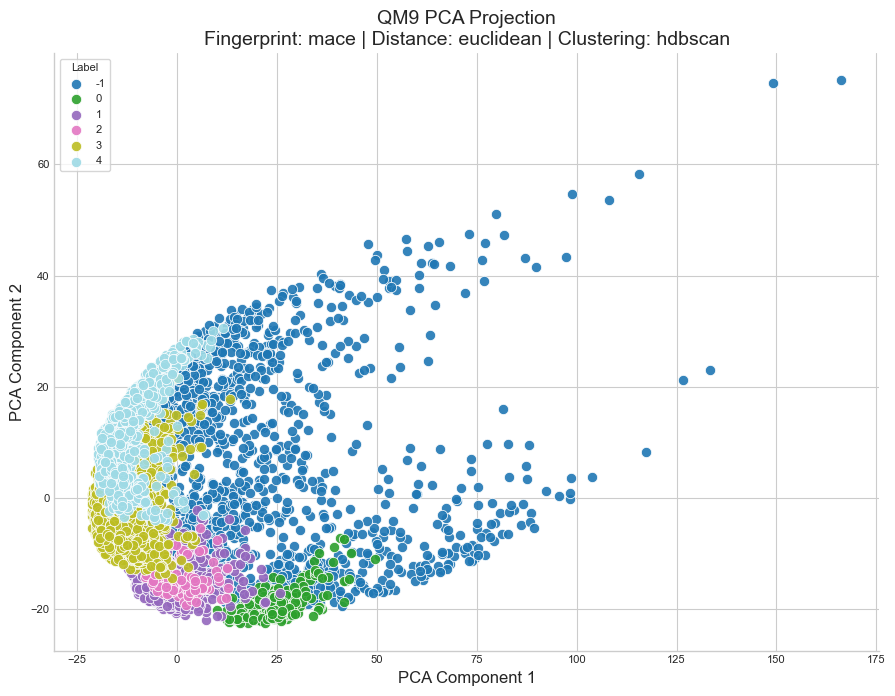

2026-05-07 08:52:24.337 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/mace/pca_hdbscan_projection.png


{'coords': array([[ 21.54159562, -14.16967919],
        [ -0.2144445 ,  -8.95798267],
        [  3.97421007,  17.05655842],
        ...,
        [-15.75932312,  -4.07954351],
        [ -2.81004095, -10.83458739],
        [ -0.57005128,  -1.391273  ]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/mace/pca_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/mace'),
 'clustering_method': 'hdbscan'}

In [32]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [33]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (6, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1696,0.865542,0.0,120.971108,-0.268868,42.376179,0.843522,12.814779,8.741156,2.026533,0.150354,0.014151,2.724057,16.316038,2.098728,1.51533,0.113678,0.25936,0.626962,1.021816,2.239387,6.025943,0.719929,1.397995,3.899175,6.095519,13.989387,1.27325,0.001179,0.304245,0.037146,0.164505,0.158019,0.004127,0.051887,0.167453,0.496462,0.00059,3.013532,71.575023,-6.607693,-0.170002,6.437654,1095.05424,3.419705,-11259.528514,-11259.314975,-11259.289283,-11260.418063,29.355377,-69.446997,-69.849249,-70.234164,-64.746215,3.627815,1.505604,1.207296,0.257665,0.573703,0.002358,0.120873,75.058962,14.445755,10.495283,13.989387,771,"""Acyclic""",10.495283,261,"""C1CC1""",11.025943,1,null,0.0
0,203,0.794064,0.0,121.630542,0.231527,48.128079,0.752132,12.847893,8.842365,0.935961,0.773399,0.0,2.975369,16.039409,1.9924,2.20197,0.082723,0.679516,0.237761,1.118227,2.359606,6.359606,0.512315,3.950739,1.403941,6.605911,12.674877,1.250431,0.029557,0.078818,0.118227,0.344828,0.152709,0.0,0.014778,0.133005,0.142857,0.0,3.308235,76.880936,-6.005888,-0.654561,5.351394,1231.220434,3.392833,-11290.304577,-11290.075794,-11290.05011,-11291.218257,30.573212,-70.915917,-71.300346,-71.683569,-66.243391,3.696231,1.34453,0.955207,0.049261,0.0,0.0,0.0,12.807882,75.862069,11.330049,12.674877,53,"""c1cc[nH]c1""",19.211823,13,"""C1CCCC1""",46.305419,1,null,0.0
1,551,0.696458,0.0,123.571688,0.088929,39.983666,0.880665,12.850802,8.807623,0.791289,0.010889,0.0,2.566243,18.313975,1.977079,2.586207,0.082354,0.305199,0.612447,0.754991,1.989111,6.288566,0.566243,1.876588,3.798548,6.508167,12.662432,1.251673,0.0,0.214156,0.0,0.181488,0.343013,0.0,0.079855,0.299456,0.406534,0.0,3.180852,75.75,-6.659416,-0.525446,6.134059,1310.179795,4.002825,-11343.377993,-11343.13082,-11343.105167,-11344.320057,32.637414,-76.541659,-76.985614,-77.420773,-71.322166,3.41875,1.247782,0.967032,0.0,0.442831,0.0,0.0,69.69147,1.088929,29.219601,12.662432,156,"""Acyclic""",29.219601,35,"""Acyclic""",29.219601,1,null,0.0
2,133,0.718197,0.0,121.037594,0.586466,37.541353,0.79155,12.887613,8.691729,1.18797,1.0,0.0,2.609023,17.969925,2.021054,3.150376,0.0,0.590494,0.409506,1.180451,2.323308,7.135338,0.0,3.56391,2.518797,6.796992,12.857143,1.244643,0.0,0.210526,0.218045,0.278195,0.0,0.0,0.0,0.0,0.233083,0.0,1.956793,76.458572,-5.302701,0.981533,6.284193,1246.626783,4.074221,-10966.52622,-10966.287117,-10966.261462,-10967.44941,31.951203,-76.324646,-76.778147,-77.21431,-71.085558,3.918417,1.314679,0.985319,0.0,0.37594,0.0,0.0,0.0,100.0,0.0,12.857143,24,"""c1cc[nH]c1""",26.315789,5,"""C1CCCC1""",81.203008,1,null,0.0
3,1482,0.706325,0.0,123.589069,0.20108,32.835358,0.902026,12.839859,8.79892,1.523617,0.0,0.0,2.138327,19.647099,2.049486,2.688934,0.058439,0.116829,0.824732,0.865722,1.798246,6.724022,0.408232,0.782726,5.469636,6.456815,13.

# KMeans

In [34]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = np.array(df['mace_embedding'].to_list())
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X_pca)
df = df.with_columns(labels_kmeans=labels_kmeans)

print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1506, 2175, 1319]))


In [35]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-07 08:52:24.845 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:52:24.848 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:53:40.956 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:53:41.087 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:53:41.559 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:53:41.695 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [36]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1506,0.826192,0.0,123.917663,-0.304117,37.707835,0.912117,12.824149,8.831341,2.50996,0.002656,0.001992,2.519256,18.179947,2.144804,1.842629,0.053736,0.052386,0.893878,1.156707,2.215803,6.500664,0.343293,0.302789,5.666003,6.059761,14.860558,1.275311,0.0,0.630146,0.000664,0.078353,0.063081,0.001328,0.049137,0.079681,…,2.617505,72.3051,-6.620635,0.93953,7.560165,1081.175477,4.01042,-11430.670952,-11430.453012,-11430.427297,-11431.558772,30.704028,-74.972263,-75.443252,-75.876992,-69.712988,3.178225,1.528847,1.269353,0.126826,0.97344,0.002656,0.09429,1.583001,98.73838,0.265604,0.996016,14.860558,709,"""C1CC1""",2.855246,263,"""C1CC2CC12""",9.163347,1,null,0.0
1,2175,0.686867,0.0,122.776092,0.394943,25.044138,0.914433,12.808719,8.786207,1.616092,0.03954,0.0,1.734253,20.285977,2.055535,2.709885,0.040382,0.15329,0.806328,0.708506,1.427586,7.184828,0.302529,1.056552,5.692874,6.457471,13.79954,1.257968,0.0,0.31954,0.004598,0.069885,0.089655,0.00092,0.023908,0.146207,…,2.295786,79.513784,-6.458893,0.591235,7.050122,1247.55144,4.675473,-10735.568816,-10735.32531,-10735.29963,-10736.490678,33.559889,-83.105683,-83.633105,-84.121528,-77.27791,3.224923,1.34574,1.096294,0.0,1.603678,0.0,0.00092,2.415632,86.942529,3.954023,9.103448,13.79954,678,"""Acyclic""",9.103448,199,"""C1CC1""",12.413793,1,null,0.0
2,1319,0.805578,0.0,120.86884,-0.075057,51.153146,0.782194,12.882604,8.685368,0.906748,0.349507,0.015921,3.15163,15.890068,1.988386,2.142532,0.131022,0.443789,0.425188,1.054587,2.507202,5.571645,0.808946,2.340409,2.384382,6.471569,12.608795,1.256983,0.006065,0.20091,0.079606,0.278999,0.296437,0.002274,0.059894,0.172858,…,3.32552,72.033723,-6.579379,-0.636864,5.942542,1213.897012,3.305001,-11414.321779,-11414.091412,-11414.065724,-11415.240387,30.375356,-68.418833,-68.790555,-69.166334,-63.850406,3.853041,1.339606,1.012839,0.21304,0.0,0.0,0.046247,-0.250948,42.987111,33.965125,23.047763,12.608795,348,"""Acyclic""",23.047763,58,"""C1CCCC1""",23.654284,1,null,0.0
